# Ablation Row 1 — Baseline (HOG-coarse only, single scale)

| | Value |
|---|---|
| Features | HOG-coarse only on 3 HSV channels (~5292-d raw) |
| PCA | 1215 components (90% variance, Gram-trick) |
| Scales | (1.0,) — single scale |
| HNM | off |
| Threshold | `cfg.detection_threshold = 1.5` (default) |

Artifacts → `microglia-artifacts-row1/`. Dalal & Triggs–style minimal pipeline.

## 1  Imports + Config

In [1]:
import os
import joblib
import numpy as np
import matplotlib.image as mpimg

from pipeline import (
    Config,
    extract_raw_features, fit_pipeline,
    tune_svm, train_svm, evaluate_classifier,
    process_image, multi_scale_detect, non_max_suppression,
    load_gt_boxes, evaluate_detections, plot_gt_vs_pred,
    save_hard_negatives, tune_detection_threshold,
    ensure_test_patches, patch_level_test_eval, detection_level_test_eval,
    extract_features, list_images,
)

%matplotlib inline

In [2]:
cfg = Config(
    artifact_dir='./microglia-artifacts-row1',
    feature_mode='hog_coarse',
    scale_factors=(1.0,),
    pca_n_components=1215,  # 90% variance — Gram-trick curve, 2026-05-23
    detection_threshold=1.5,
)
os.makedirs(cfg.artifact_dir, exist_ok=True)
print(cfg)

Config(image_rois_csv='../Image_ROIs.csv', source_images='../Source_images', test_dir='../test_images', microglia_folder='./Processed_training_images/Train/Microglia', noise_folder='./Processed_training_images/Train/Noise', microglia_val_folder='./Processed_training_images/Validate/Microglia', noise_val_folder='./Processed_training_images/Validate/Noise', microglia_test_folder='./Processed_training_images/Test/Microglia', noise_test_folder='./Processed_training_images/Test/Noise', hnm_folder='./Processed_training_images/HardNegatives', artifact_dir='./microglia-artifacts-row1', features_cache='./microglia-artifacts-row1/features_cache.npz', svm_clf_path='./microglia-artifacts-row1/svm_clf.pkl', scaler_path='./microglia-artifacts-row1/scaler.pkl', pca_path='./microglia-artifacts-row1/pca.pkl', val_paths_cache='./microglia-artifacts-row1/val_paths.txt', hnm_train_final='./microglia-artifacts-row1/hnm_train_final.npz', image_size=2048, window_size=64, feature_mode='hog_coarse', scale_fact

## 2  Train (features → PCA → tune C → fit SVM)

In [3]:
# Train/Validate patches + HOG-coarse features are already on disk from the
# initial extraction run. To rebuild from source uncomment:
# from pipeline import preprocess_all_images
# train_paths, val_paths = preprocess_all_images(cfg)
# X_train_raw, X_val_raw, y_train_raw, y_val_raw = extract_raw_features(cfg)
# np.savez_compressed(cfg.features_cache,
#                     X_train_raw=X_train_raw, X_val_raw=X_val_raw,
#                     y_train_raw=y_train_raw, y_val_raw=y_val_raw)

# ── Load cached features ───────────────────────────────────────────
cache       = np.load(cfg.features_cache)
X_train_raw = cache["X_train_raw"]
X_val_raw   = cache["X_val_raw"]
y_train_raw = cache["y_train_raw"]
y_val_raw   = cache["y_val_raw"]
print(f"Loaded cache: X_train_raw={X_train_raw.shape}, X_val_raw={X_val_raw.shape}")

# ── Fit scaler + PCA(1215) → tune C → train SVM ─────────────────────────
X_train, X_val, y_train, y_val, scaler, pca = fit_pipeline(
    X_train_raw, X_val_raw, y_train_raw, y_val_raw, cfg
)

best_params = tune_svm(X_train, y_train, cfg)
svm_clf     = train_svm(X_train, y_train, cfg)

joblib.dump(svm_clf, cfg.svm_clf_path)
joblib.dump(scaler,  cfg.scaler_path)
joblib.dump(pca,     cfg.pca_path)
print(f"Saved artifacts → {cfg.artifact_dir}/")

print("\nValidate patch-level metrics:")
evaluate_classifier(svm_clf, X_val, y_val, label='val')


Loaded cache: X_train_raw=(14914, 5292), X_val_raw=(3036, 5292)


PCA: 5292 → 1215 components (89.7% variance retained)
Train: 14914 | Validate: 3036
Fitting 5 folds for each of 6 candidates, totalling 30 fits



C        mean-F1  std-F1
0.001    0.9225   ±0.0070 ← best
0.01     0.9047   ±0.0058
0.1      0.8897   ±0.0077
1.0      0.8881   ±0.0080
10.0     0.8881   ±0.0074
100.0    0.8880   ±0.0076

Best params : {'C': 0.001}
Best CV F1  : 0.9225


Training time : 2.75s
Saved artifacts → ./microglia-artifacts-row1/

Validate patch-level metrics:
[val] Accuracy  : 0.9391
[val] Precision : 0.4484
[val] Recall    : 0.9085
[val] F1-Score  : 0.6004


## 3  Held-out test evaluation

── Patch-level test ──


  [test microglia] 245/245 (100%) — 245 feature vectors extracted


  [test noise] 1922/1922 (100%) — 1922 feature vectors extracted


[test] Accuracy  : 0.7702
[test] Precision : 0.3284
[test] Recall    : 0.9878
[test] F1-Score  : 0.4929

── Detection-level test (single scale, t=1.50) ──
Running detection on 2 test images at scales (1.0,), threshold=1.50

── 13_s46 ──
  scale=1.00 (2048×2048px)  

      0% 

...

     67% 

     77% 

     87% 

     96% 

100%
  → 1133 candidates at this scale
  Total candidates : 1133
  After NMS        : 406
  Detection time: 7.1s
  GT=123  Pred=406  TP=38  FP=368  FN=85  P=0.094  R=0.309


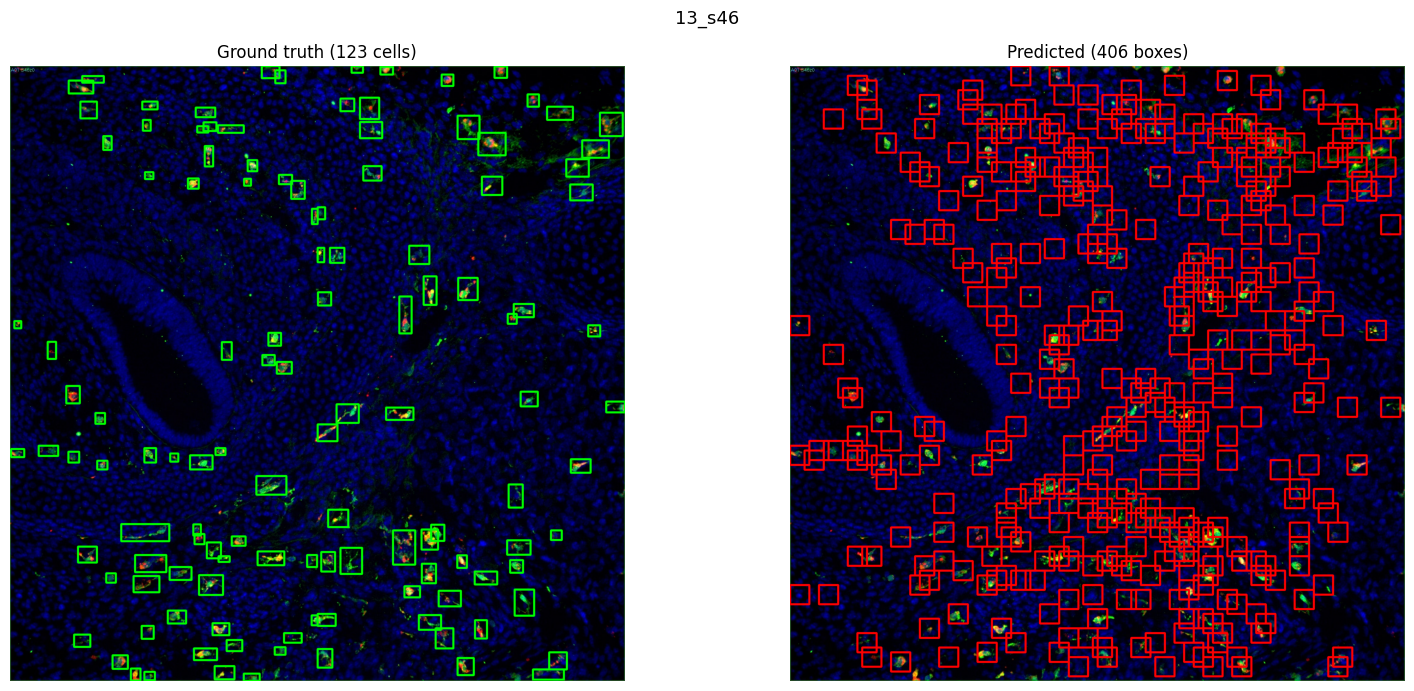


── 14_s47 ──
  scale=1.00 (2048×2048px)  

      0% 

      9% 

     19% 

     29% 

...

     67% 

     77% 

     87% 

     96% 

100%
  → 1174 candidates at this scale
  Total candidates : 1174
  After NMS        : 433
  Detection time: 7.2s
  GT=122  Pred=433  TP=43  FP=390  FN=79  P=0.099  R=0.352


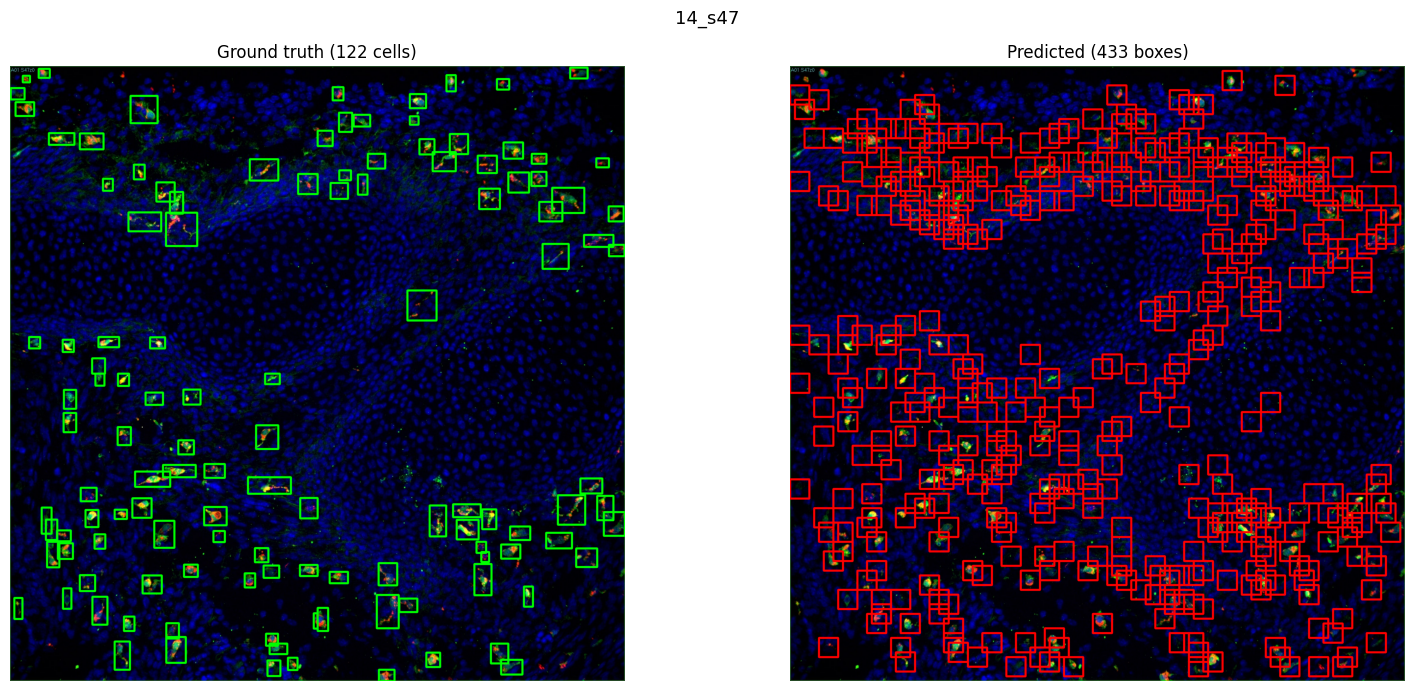


== AGGREGATE  TP=81  FP=758  FN=164
   Precision=0.097  Recall=0.331  F1=0.149


In [4]:
ensure_test_patches(cfg)

print("── Patch-level test ──")
patch_level_test_eval(svm_clf, scaler, pca, cfg)

print("\n── Detection-level test (single scale, t=%.2f) ──" % cfg.detection_threshold)
row1_metrics = detection_level_test_eval(svm_clf, scaler, pca, cfg, show_plots=True)